In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
# from sklearn.model.selection import train_test_split
# from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# from sklearn.ensemble import RandomForestRegressor 
# from xgboost import XGBRegressor
# from lightgbm import LGBMRegressor

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 5)

import warnings 
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


In [ ]:
df = pd.read_csv('../data/datos.csv')

print("Shape:",df.shape)
df.head()

Shape: (97377, 12)


,model_name,organization,license,rating,rating_lower,rating_upper,variance,vote_count,rank,category,leaderboard_publish_date,subset
0,vicuna-13b,LMSYS,Llama 2 Community,1094.0,NaN,NaN,NaN,NaN,1.0,overall,2023-05-08,text
1,koala-13b,UC Berkeley,Non-commercial,1015.0,NaN,NaN,NaN,NaN,2.0,overall,2023-05-08,text
2,RWKV-4-Raven-14B,RWKV,Apache 2.0,979.0,NaN,NaN,NaN,NaN,3.0,overall,2023-05-08,text
3,oasst-pythia-12b,OpenAssistant,Apache 2.0,941.0,NaN,NaN,NaN,NaN,4.0,overall,2023-05-08,text
4,alpaca-13b,Stanford,Non-commercial,935.0,NaN,NaN,NaN,NaN,5.0,overall,2023-05-08,text


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97377 entries, 0 to 97376
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   model_name                97377 non-null  object 
 1   organization              93900 non-null  object 
 2   license                   97246 non-null  object 
 3   rating                    97377 non-null  float64
 4   rating_lower              97070 non-null  float64
 5   rating_upper              97070 non-null  float64
 6   variance                  97070 non-null  float64
 7   vote_count                97070 non-null  float64
 8   rank                      97377 non-null  float64
 9   category                  97377 non-null  object 
 10  leaderboard_publish_date  97377 non-null  object 
 11  subset                    97377 non-null  object 
dtypes: float64(6), object(6)
memory usage: 8.9+ MB


# Exploratory data analysis (EDA)

**Column notes:**
- rating --> the Elo-style Arena score
- rating_lower, rating_upper, variance --> confidence interval built directly from rating
- rank --> is rating but sorted
- model_name --> 
- organization, license, subset 
- vote_count 
- leaderboard_publish_date
- category

In [4]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nUnique models:", df['model_name'].nunique())
print("\nUnique organizations:", df['organization'].nunique())
print("\nSubset counts:\n", df['subset'].value_counts())
print("\nDate range:", df['leaderboard_publish_date'].min(), "to", df['leaderboard_publish_date'].max())

Missing values:
 model_name                     0
organization                3477
license                      131
rating                         0
rating_lower                 307
rating_upper                 307
variance                     307
vote_count                   307
rank                           0
category                       0
leaderboard_publish_date       0
subset                         0
dtype: int64

Duplicate rows: 0

Unique models: 461

Unique organizations: 65

Subset counts:
 subset
text                  45123
text_style_control    40141
vision                 8229
webdev                 3292
search                  592
Name: count, dtype: int64

Date range: 2023-05-08 to 2026-07-10


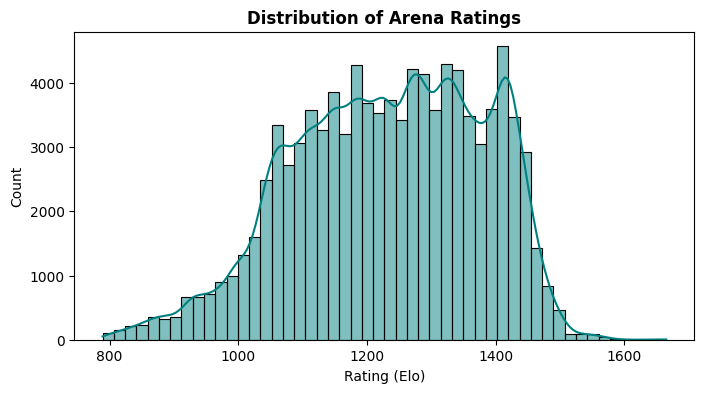

In [5]:
plt.figure(figsize=(8,4))
sns.histplot(df['rating'], bins=50, kde=True, color='teal')
plt.title('Distribution of Arena Ratings',fontweight='bold')
plt.xlabel('Rating (Elo)')
plt.show()

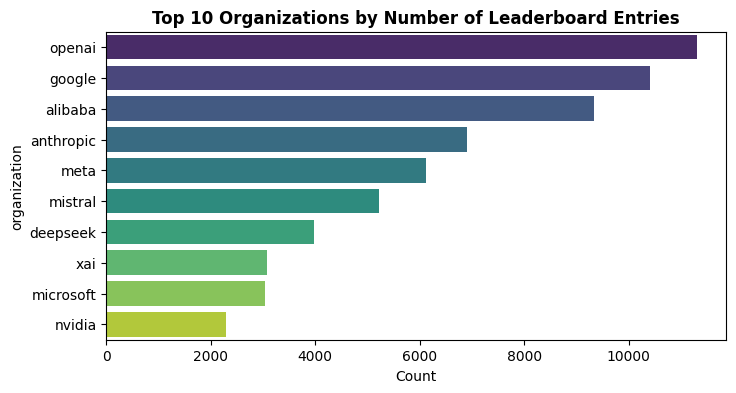

In [6]:
top_orgs = df['organization'].value_counts().head(10)
plt.figure(figsize=(8,4))
sns.barplot(x=top_orgs.values, y=top_orgs.index, palette='viridis')
plt.title('Top 10 Organizations by Number of Leaderboard Entries',fontweight='bold')
plt.xlabel('Count')
plt.show()

# Construccio de la serie objetivo "Frontier Elo" 

Nos quedamos con el subset `text` (el arena principal, con mas historia) y calculamos, para cada fecga de publicacion del leaderboard, el rating maximo observado (el mejor modelo del momento)

In [7]:
df_text = df[df['subset'] == 'text'].copy()
df_text['leaderboard_publish_date'] = pd.to_datetime(df_text['leaderboard_publish_date'])

frontier = df_text.groupby('leaderboard_publish_date')['rating'].max().sort_index()
frontier.name = 'elo_max'

print(f"Observaciones (fechas irregulares): {len(frontier)}")
frontier.head(10)


Observaciones (fechas irregulares): 223


leaderboard_publish_date
2023-05-08    1094.000000
2023-05-22    1075.000000
2023-06-19    1065.000000
2023-07-17    1096.000000
2023-08-02    1096.000000
2023-09-05    1097.000000
2023-10-02    1099.000000
2023-11-08    1096.000000
2023-11-16    1093.000000
2023-12-06    1124.958826
Name: elo_max, dtype: float64

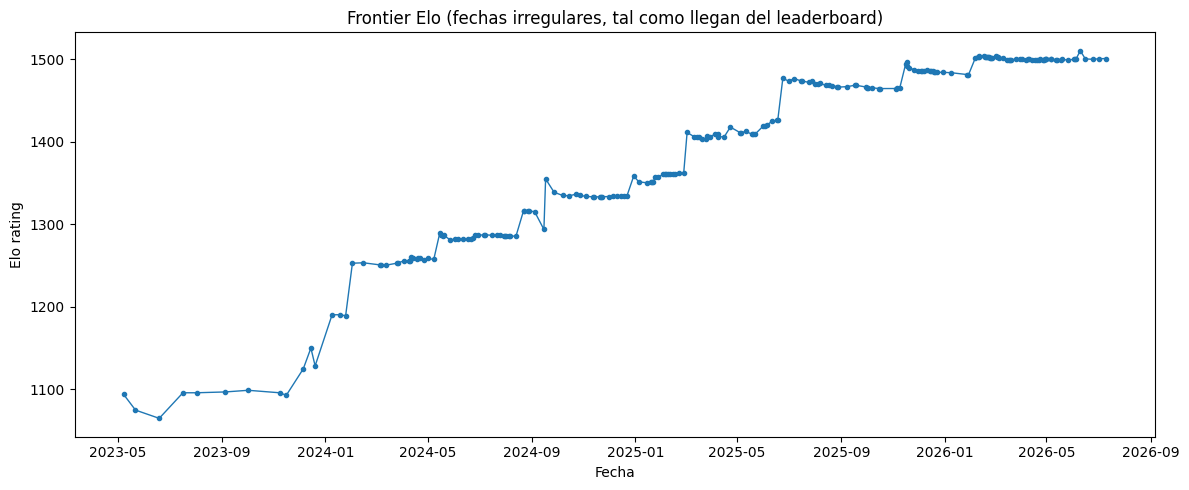

In [8]:
fig, ax = plt.subplots()
ax.plot(frontier.index, frontier.values, marker='o', markersize=3, linewidth=1)
ax.set_title('Frontier Elo (fechas irregulares, tal como llegan del leaderboard)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Elo rating')
plt.tight_layout()
plt.savefig('../results/01_serie_original_irregular.png', dpi=120)
plt.show()

# Re - muestreo a frecuencia semanal fija + forward fill 

Las publicaciones del leaderboard no ocurren a intervalos regulares (a veces cada semana, a veces cada 3-4 semanas). Para poder aplicar modelos que asumen una escala de tiempo fija (como SARIMA) re-muestreamos a frecuencia **semanal**: en las semanas sin una nueva publicacion, se mantiene el ultimo valor conocido (forward fill), ya que es el 'mejor modelo del momento' tecnicamente no cambia hasta que uno nuevo lo supere. 

In [9]:
frontier_weekly = frontier.resample('W').last().ffill()

#si la primera fecha del rango semanal quedo con NaN (antes de la primera medicion real), la eliminamos
frontier_weekly = frontier_weekly.dropna()

print(f"Observaciones despues del resample semanal: {len(frontier_weekly)}")
frontier_weekly.head(10)

Observaciones despues del resample semanal: 166


leaderboard_publish_date
2023-05-14    1094.0
2023-05-21    1094.0
2023-05-28    1075.0
2023-06-04    1075.0
2023-06-11    1075.0
2023-06-18    1075.0
2023-06-25    1065.0
2023-07-02    1065.0
2023-07-09    1065.0
2023-07-16    1065.0
Freq: W-SUN, Name: elo_max, dtype: float64

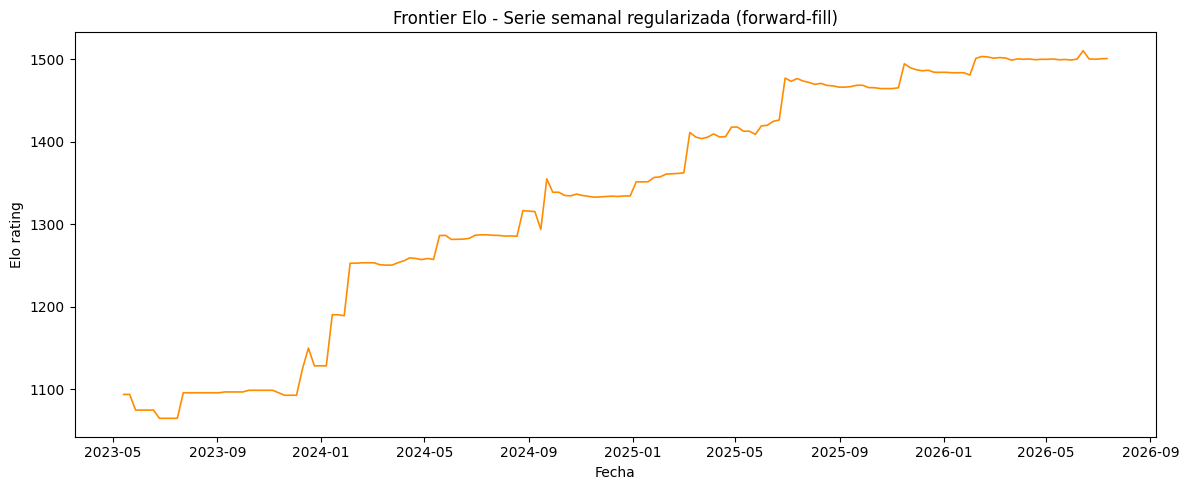

In [10]:
fig, ax = plt.subplots()
ax.plot(frontier_weekly.index, frontier_weekly.values, linewidth=1.2, color='darkorange')
ax.set_title('Frontier Elo - Serie semanal regularizada (forward-fill)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Elo rating')
plt.tight_layout()
plt.savefig('../results/02_serie_semanal_regularizada.png', dpi=120)
plt.show()

# Verificacion de estacionariedad y estacionalidad 

Antes de modelar, revisamos si la serie tiene tendencia y si hay algun patron estacional aparente en la composicion 

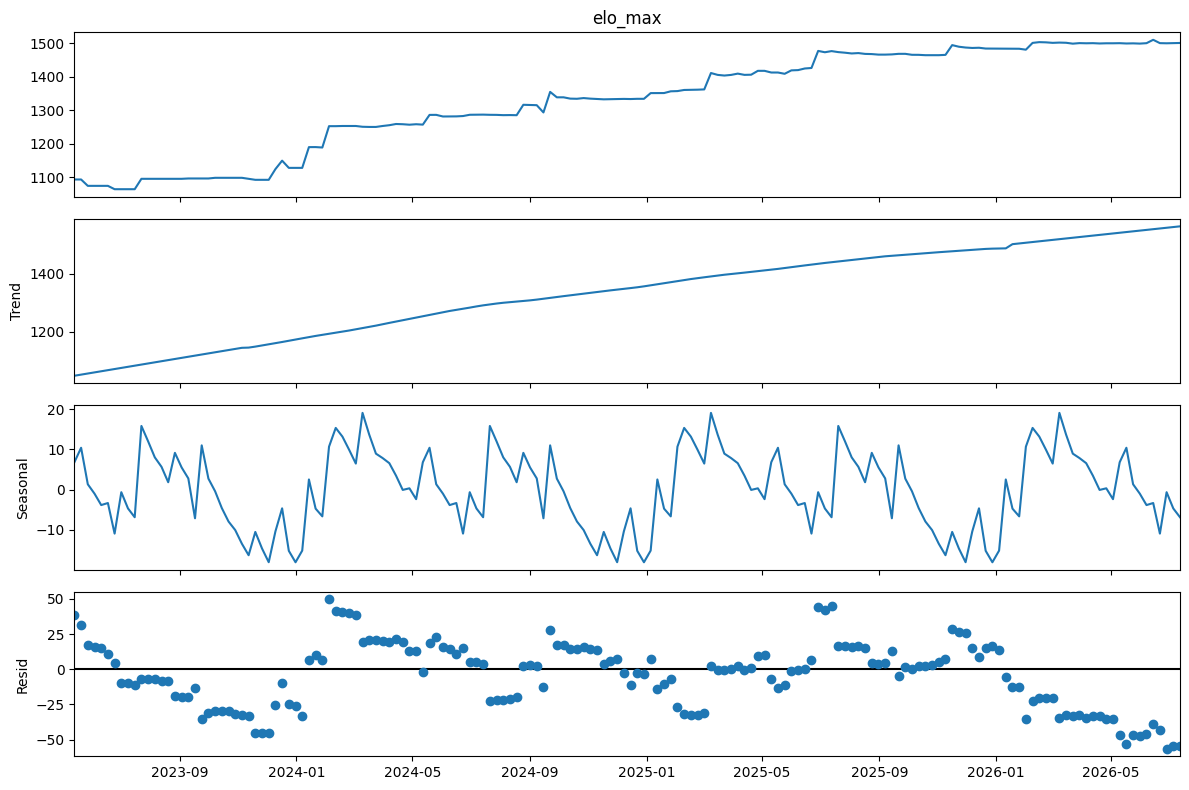

In [11]:
#Descomposicion

descomposition = seasonal_decompose(frontier_weekly, model='additive', period=52, extrapolate_trend='freq') 

fig = descomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.savefig('../results/03_descomposicion.png', dpi=120)
plt.show()

In [12]:
# Test de Dickey-Fuller aumentado (estacionariedad)
result = adfuller(frontier_weekly.dropna())
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print('La serie NO es estacionaria' if result[1] > 0.05
      else 'La serie es estacionaria')


ADF Statistic: -1.1319
p-value: 0.7022
La serie NO es estacionaria



# Feature engineering 

Creamos lags, medias moviles y feature de calendario ciclicas 

In [13]:
feat = frontier_weekly.to_frame()

# Lags
for lag in [1, 2, 4, 8, 12]:
    feat[f'lag_{lag}'] = feat['elo_max'].shift(lag)

# Medias moviles y desvio
feat['roll_mean_4'] = feat['elo_max'].shift(1).rolling(4).mean()
feat['roll_mean_12'] = feat['elo_max'].shift(1).rolling(12).mean()
feat['roll_std_4'] = feat['elo_max'].shift(1).rolling(4).std()

# Features de calendario ciclicas (semana del año)
feat['week_of_year'] = feat.index.isocalendar().week.astype(int)
feat['week_sin'] = np.sin(2 * np.pi * feat['week_of_year'] / 52)
feat['week_cos'] = np.cos(2 * np.pi * feat['week_of_year'] / 52)

# Tendencia (indice temporal simple)
feat['t'] = np.arange(len(feat))

feat = feat.dropna()
print(feat.shape)
feat.head()


(154, 13)


,elo_max,lag_1,lag_2,lag_4,lag_8,lag_12,roll_mean_4,roll_mean_12,roll_std_4,week_of_year,week_sin,week_cos,t
leaderboard_publish_date,,,,,,,,,,,,,
2023-08-06,1096.0,1096.0,1096.0,1065.0,1075.0,1094.0,1080.50,1078.333333,17.897858,31,-0.568065,-0.822984,12
2023-08-13,1096.0,1096.0,1096.0,1065.0,1075.0,1094.0,1088.25,1078.500000,15.500000,32,-0.663123,-0.748511,13
2023-08-20,1096.0,1096.0,1096.0,1096.0,1065.0,1075.0,1096.00,1078.666667,0.000000,33,-0.748511,-0.663123,14
2023-08-27,1096.0,1096.0,1096.0,1096.0,1065.0,1075.0,1096.00,1080.416667,0.000000,34,-0.822984,-0.568065,15
2023-09-03,1096.0,1096.0,1096.0,1096.0,1065.0,1075.0,1096.00,1082.166667,0.000000,35,-0.885456,-0.464723,16


# Split train/test --> Respetanto el orden temporal


In [14]:
test_size = 12  # ultimas 12 semanas (~3 meses) como test
train = feat.iloc[:-test_size]
test = feat.iloc[-test_size:]

print(f"Train: {train.index.min()} -> {train.index.max()}  ({len(train)} obs)")
print(f"Test:  {test.index.min()} -> {test.index.max()}  ({len(test)} obs)")

# Guardamos para los siguientes notebooks
feat.to_csv('../data/features_semanal.csv')
frontier_weekly.to_csv('../data/serie_semanal.csv')

Train: 2023-08-06 00:00:00 -> 2026-04-19 00:00:00  (142 obs)
Test:  2026-04-26 00:00:00 -> 2026-07-12 00:00:00  (12 obs)


# Conclusiones del preprocesamiento

- Se contruyo la serie "Frontier Elo" a partir del maximo rating por fecha en el arena de texto 
- Se regularizo a frecuencia semanal mediante forward-fill, obteniendo una serie apta para sariam 
- La serie es no estacionaria(tendencia creciente, confirmado por el ADF test)
- Se generaron features de lags, rolling stats y calendario ciclico para los modelos de ML 
- Split train/test respetando el orden temporal